# Wine Quality Prediction Using Machine Learning

## Project Overview

This project applies machine learning techniques to predict the quality of red wine using physicochemical properties from the UCI Wine Quality dataset. The workflow includes data preprocessing, exploratory data analysis (EDA), model training, evaluation, feature selection, hyperparameter tuning, and model interpretation using SHAP.

## Dataset

The dataset used in this project is the **Wine Quality (Red Wine)** dataset from the UCI Machine Learning Repository. It contains physicochemical measurements of red wine samples, while the target variable represents the wine quality score assigned by experts.

In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Wine Quality dataset from the UCI Machine Learning Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Display the first five rows
df.head()

# Display dataset dimensions
df.shape

# Display column names
df.columns

# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [39]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()

print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


Number of duplicate records: 240
Percentage of duplicate records: 15.01%
Dataset shape after removing duplicates: (1359, 12)
Remaining duplicate records: 0


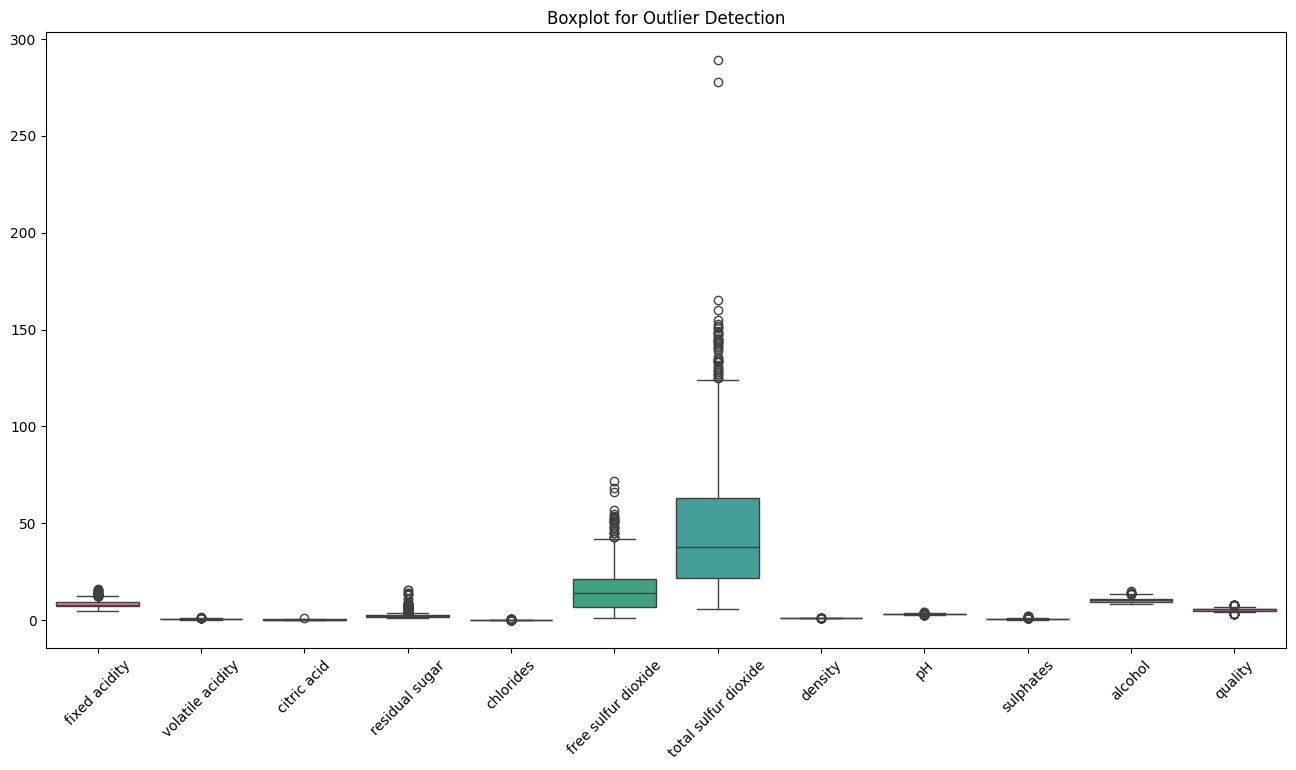

In [40]:
# Check for duplicate records
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count}")
print(f"Percentage of duplicate records: {duplicate_count / len(df) * 100:.2f}%")

# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataset shape after removing duplicates: {df.shape}")
print(f"Remaining duplicate records: {df.duplicated().sum()}")

# Boxplot for outlier detection
plt.figure(figsize=(16, 8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

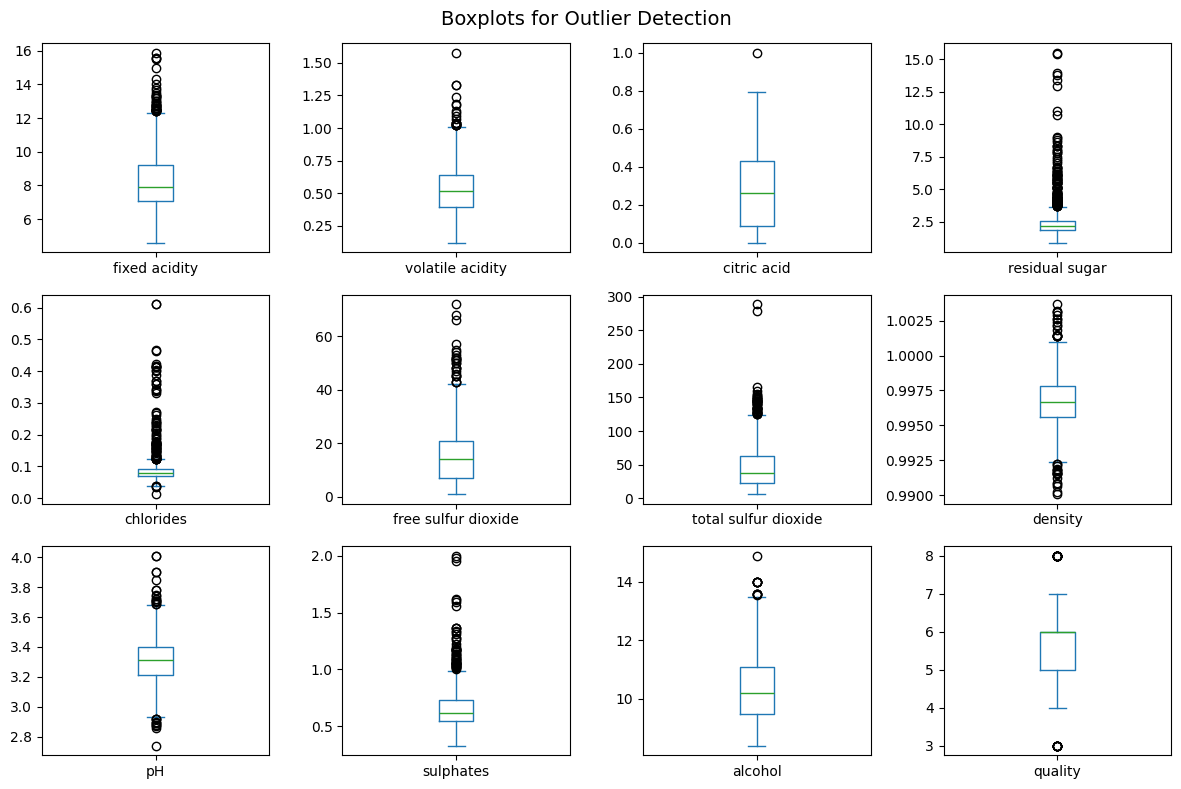

In [41]:
# Boxplots for outlier detection
df.plot(
    kind='box',
    subplots=True,
    layout=(3, 4),
    figsize=(12, 8)
)

plt.suptitle("Boxplots for Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
# Summary statistics
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


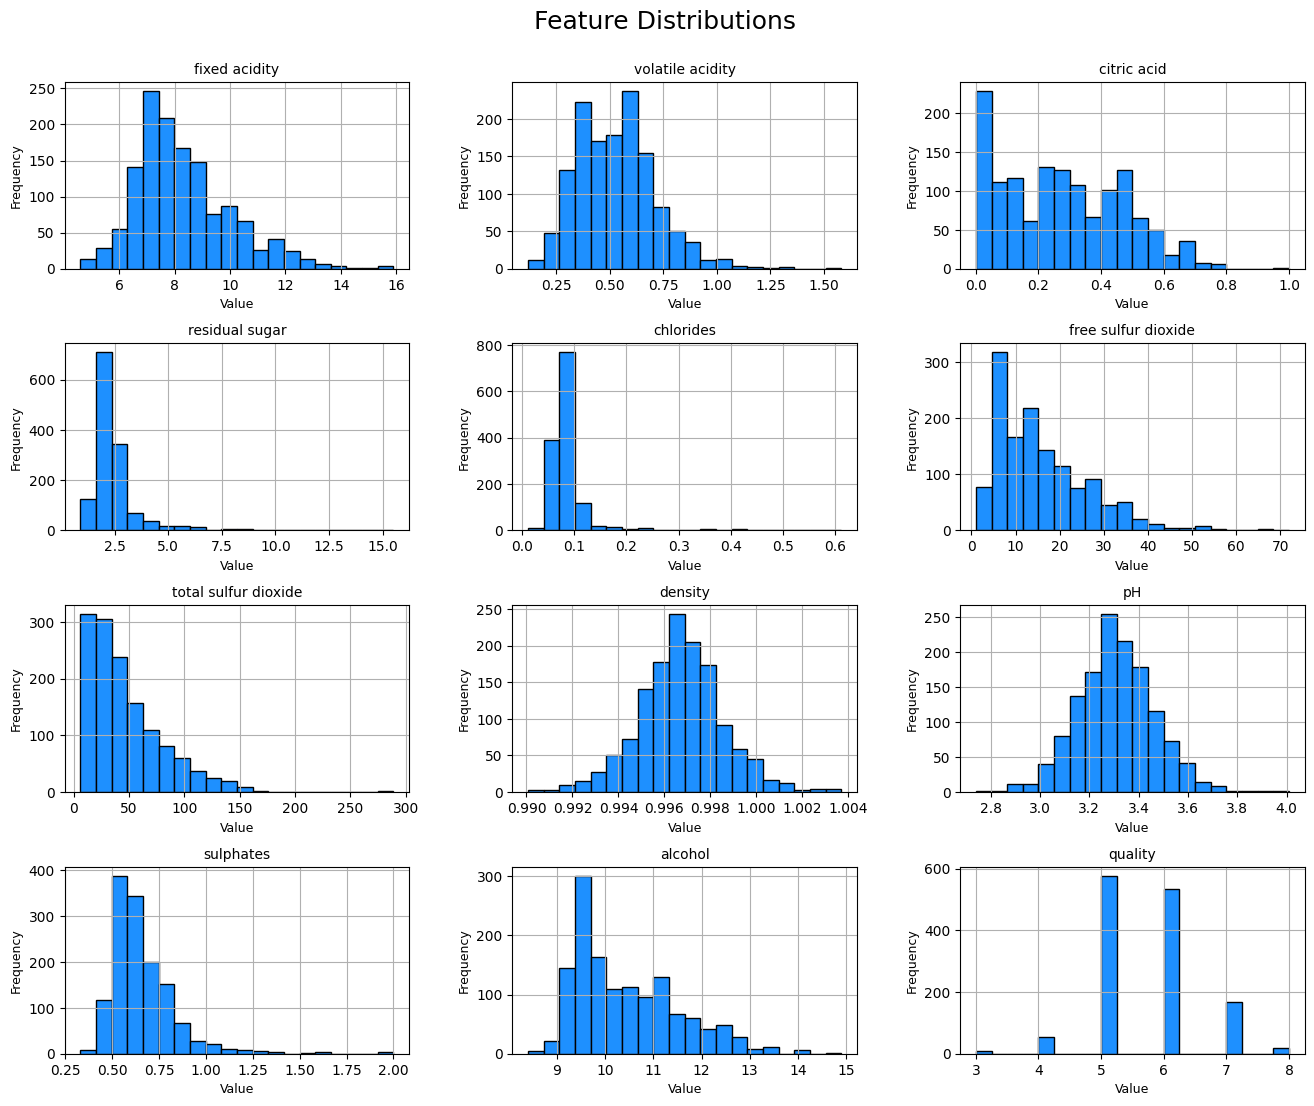

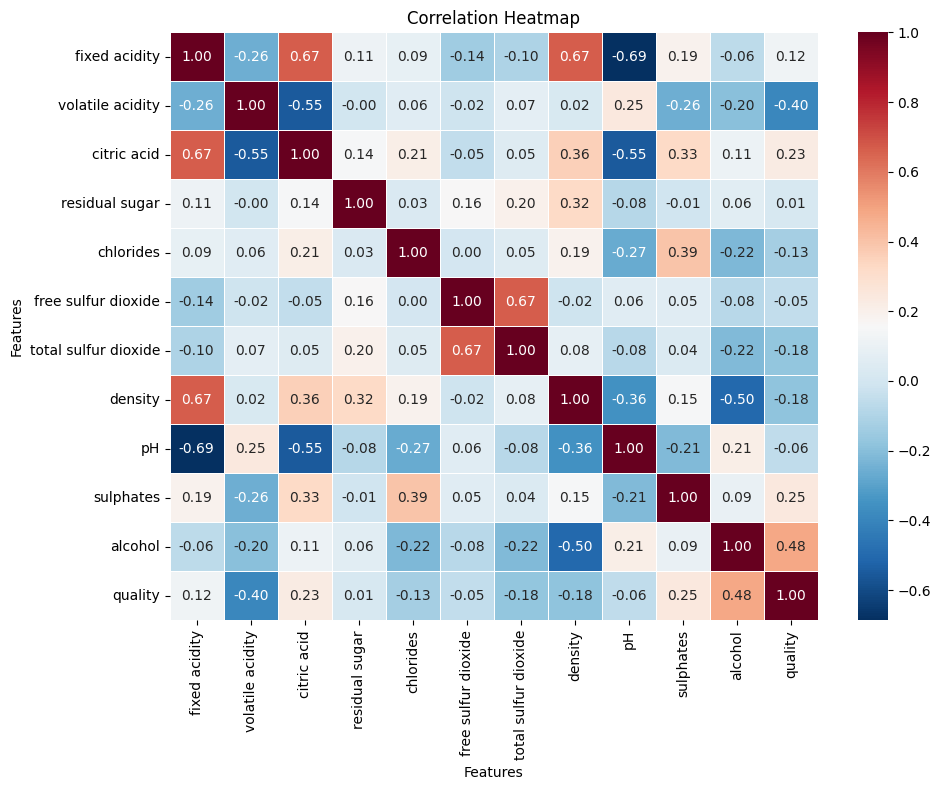

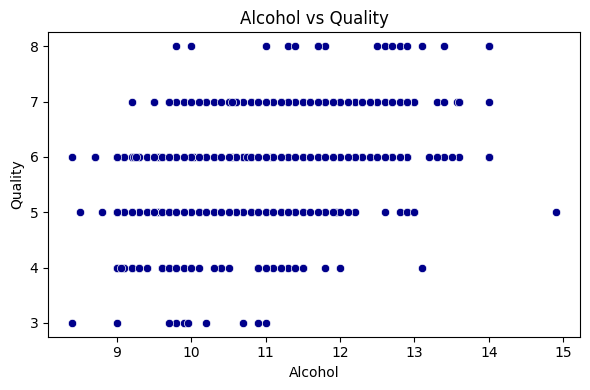

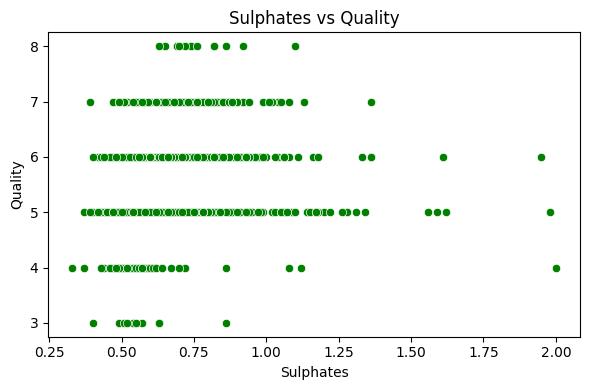

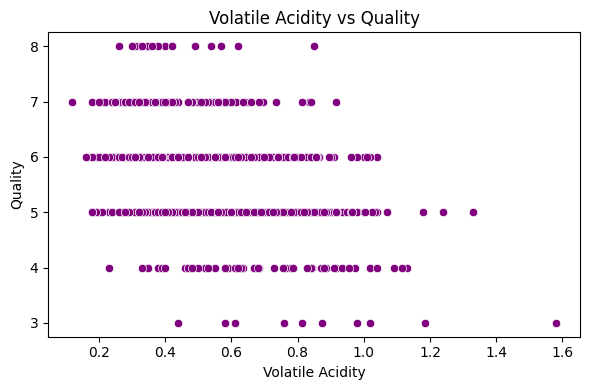

In [45]:
# Data Visualizations

# Histograms
axes = df.hist(
    figsize=(16, 12),
    bins=20,
    color='dodgerblue',
    edgecolor='black'
)

for ax in axes.flatten():
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.set_title(ax.get_title(), fontsize=10)

plt.suptitle("Feature Distributions", fontsize=18)
plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
plt.show()


# Correlation Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='RdBu_r',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


# Alcohol vs Quality
plt.figure(figsize=(6, 4))

sns.scatterplot(
    x='alcohol',
    y='quality',
    data=df,
    color='darkblue'
)

plt.title("Alcohol vs Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.tight_layout()
plt.show()


# Sulphates vs Quality
plt.figure(figsize=(6, 4))

sns.scatterplot(
    x='sulphates',
    y='quality',
    data=df,
    color='green'
)

plt.title("Sulphates vs Quality")
plt.xlabel("Sulphates")
plt.ylabel("Quality")
plt.tight_layout()
plt.show()


# Volatile Acidity vs Quality
plt.figure(figsize=(6, 4))

sns.scatterplot(
    x='volatile acidity',
    y='quality',
    data=df,
    color='purple'
)

plt.title("Volatile Acidity vs Quality")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality")
plt.tight_layout()
plt.show()

In [46]:
#  Train-Test Split

from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display dataset dimensions
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1087, 11)
Testing set: (272, 11)


In [47]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test)

In [21]:
# Train Baseline Models

# Import regression algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


# Initialize models with default parameters
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(random_state=42)
forest_model = RandomForestRegressor(random_state=42)
svr_model = SVR()
knn_model = KNeighborsRegressor()


# Train models that require feature scaling
linear_model.fit(X_train_scaled, y_train)
svr_model.fit(X_train_scaled, y_train)
knn_model.fit(X_train_scaled, y_train)


# Train tree-based models (scaling is not required)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)


# Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Generate predictions

# Models trained on scaled data
y_pred_linear = linear_model.predict(X_test_scaled)
y_pred_svr = svr_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

# Models trained on original data
y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)


# Function to evaluate model performance
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2


# Evaluate all models
results = {}

results["Linear Regression"] = evaluate_model(y_test, y_pred_linear)
results["SVR"] = evaluate_model(y_test, y_pred_svr)
results["KNN"] = evaluate_model(y_test, y_pred_knn)
results["Decision Tree"] = evaluate_model(y_test, y_pred_tree)
results["Random Forest"] = evaluate_model(y_test, y_pred_forest)


# Display evaluation metrics
for model, metrics in results.items():
    print(model)
    print(f"MAE : {metrics[0]:.4f}")
    print(f"MSE : {metrics[1]:.4f}")
    print(f"RMSE: {metrics[2]:.4f}")
    print(f"R²  : {metrics[3]:.4f}")
    print("-" * 30)

Linear Regression
MAE: 0.5041
MSE: 0.4310
RMSE: 0.6565
R2: 0.3915
------------------------------
SVR
MAE: 0.4655
MSE: 0.3972
RMSE: 0.6302
R2: 0.4393
------------------------------
KNN
MAE: 0.5397
MSE: 0.5082
RMSE: 0.7129
R2: 0.2825
------------------------------
Decision Tree
MAE: 0.6544
MSE: 0.9118
RMSE: 0.9549
R2: -0.2872
------------------------------
Random Forest
MAE: 0.4661
MSE: 0.3778
RMSE: 0.6147
R2: 0.4667
------------------------------


In [48]:
# Comparison of Baseline Models

# Create a DataFrame with the evaluation metrics
results_df = pd.DataFrame(results).T
results_df.columns = ["MAE", "MSE", "RMSE", "R²"]

# Round values for better readability
results_df = results_df.round(4)

# Display the results
results_df

,MAE,MSE,RMSE,R²
Linear Regression,0.5041,0.4310,0.6565,0.3915
SVR,0.4655,0.3972,0.6302,0.4393
KNN,0.5397,0.5082,0.7129,0.2825
Decision Tree,0.6544,0.9118,0.9549,-0.2872
Random Forest,0.4661,0.3778,0.6147,0.4667


In [49]:
# K-Fold Cross-Validation (k = 5)

from sklearn.model_selection import cross_val_score

# Define the regression models
models = {
    "Linear Regression": linear_model,
    "SVR": svr_model,
    "KNN": knn_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

# Perform 5-fold cross-validation
cv_results = {}

for name, model in models.items():

    # Models trained on scaled features
    if name in ["Linear Regression", "SVR", "KNN"]:
        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        )

    # Tree-based models trained on original features
    else:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="r2"
        )

    cv_results[name] = {
        "Mean R²": np.mean(scores),
        "Std R²": np.std(scores)
    }

# Display cross-validation results
for model, values in cv_results.items():
    print(model)
    print(f"Mean R²: {values['Mean R²']:.4f}")
    print(f"Std R² : {values['Std R²']:.4f}")
    print("-" * 30)

Linear Regression
Mean R²: 0.3359
Std R² : 0.0209
------------------------------
SVR
Mean R²: 0.3359
Std R² : 0.0260
------------------------------
KNN
Mean R²: 0.2280
Std R² : 0.0362
------------------------------
Decision Tree
Mean R²: -0.2958
Std R² : 0.1089
------------------------------
Random Forest
Mean R²: 0.3446
Std R² : 0.0288
------------------------------


In [51]:
# Feature Selection using Correlation Analysis

# Calculate the correlation of each feature with the target variable
correlation = df.corr()["quality"].sort_values(ascending=False)

# Display the correlation values
print(correlation)

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


In [52]:
# Feature Selection using Recursive Feature Elimination (RFE)

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Initialize the base model
model = LinearRegression()

# Select the top 5 most important features
rfe = RFE(
    estimator=model,
    n_features_to_select=5
)

# Fit RFE on the training data
rfe.fit(X_train_scaled, y_train)

# Display the selected features
selected_features = X.columns[rfe.support_]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['volatile acidity', 'chlorides', 'total sulfur dioxide', 'sulphates',
       'alcohol'],
      dtype='object')


In [54]:

#  Comparison: All Features vs Selected Features

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Model using all features


model_all = LinearRegression()
model_all.fit(X_train_scaled, y_train)

y_pred_all = model_all.predict(X_test_scaled)

rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))
r2_all = r2_score(y_test, y_pred_all)


# Model using RFE-selected features

selected_indices = [list(X.columns).index(feature) for feature in selected_features]

X_train_sel = X_train_scaled[:, selected_indices]
X_test_sel = X_test_scaled[:, selected_indices]

model_sel = LinearRegression()
model_sel.fit(X_train_sel, y_train)

y_pred_sel = model_sel.predict(X_test_sel)

rmse_sel = np.sqrt(mean_squared_error(y_test, y_pred_sel))
r2_sel = r2_score(y_test, y_pred_sel)


# Display results

print("Model using all features")
print(f"RMSE: {rmse_all:.4f}")
print(f"R²: {r2_all:.4f}")

print("\nModel using RFE-selected features")
print(f"RMSE: {rmse_sel:.4f}")
print(f"R²: {r2_sel:.4f}")

Model using all features
RMSE: 0.6565
R²: 0.3915

Model using RFE-selected features
RMSE: 0.6478
R²: 0.4075


In [55]:
# Hyperparameter Tuning using Grid Search

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Random Forest
rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Random Forest")
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Best Cross-Validation R²: {grid_rf.best_score_:.4f}")


# Support Vector Regression

svr = SVR()

param_grid_svr = {
    "C": [0.1, 1, 10],
    "epsilon": [0.1, 0.2],
    "kernel": ["rbf"]
}

grid_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_svr.fit(X_train_scaled, y_train)

print("\nSupport Vector Regression")
print(f"Best Parameters: {grid_svr.best_params_}")
print(f"Best Cross-Validation R²: {grid_svr.best_score_:.4f}")

Random Forest
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation R²: 0.3490

Support Vector Regression
Best Parameters: {'C': 1, 'epsilon': 0.2, 'kernel': 'rbf'}
Best Cross-Validation R²: 0.3441


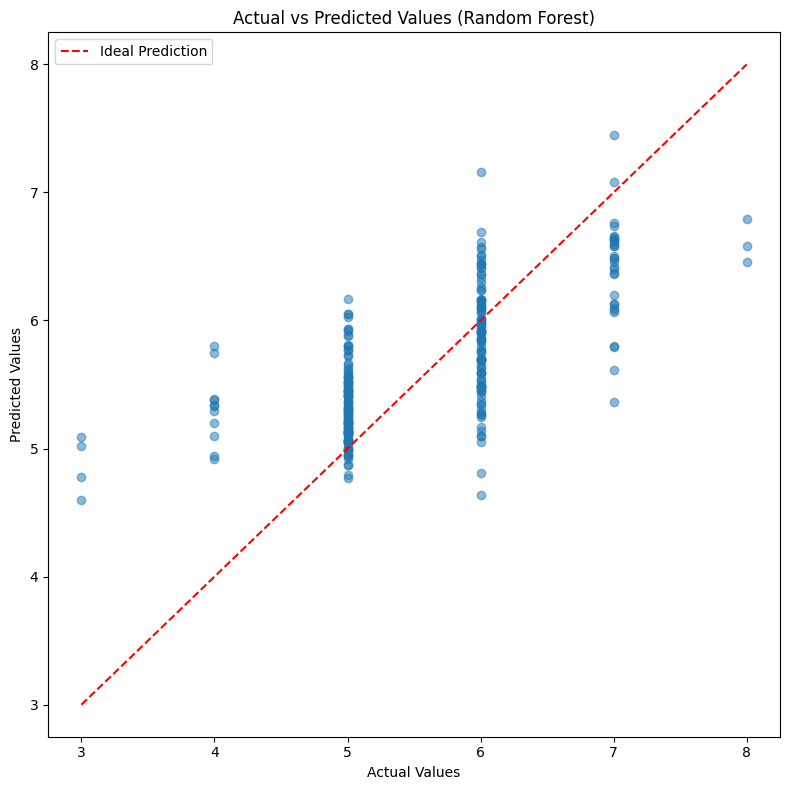

In [56]:
# Actual vs Predicted Values

# Generate predictions using the Random Forest model
y_pred = forest_model.predict(X_test)

# Create the scatter plot
plt.figure(figsize=(8, 8))

# Plot actual vs predicted values
plt.scatter(y_test, y_pred, alpha=0.5)

# Plot the ideal prediction line (y = x)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Ideal Prediction"
)

# Axis labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Title
plt.title("Actual vs Predicted Values (Random Forest)")

# Legend
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
#  Residual Analysis

# Calculate prediction residuals
residuals = y_test - y_pred

# Display the first residual values
print("First five residuals:")
print(residuals.head())

First five residuals:
51      0.06
1100    0.08
1312    0.60
514    -0.49
1074   -1.34
Name: quality, dtype: float64


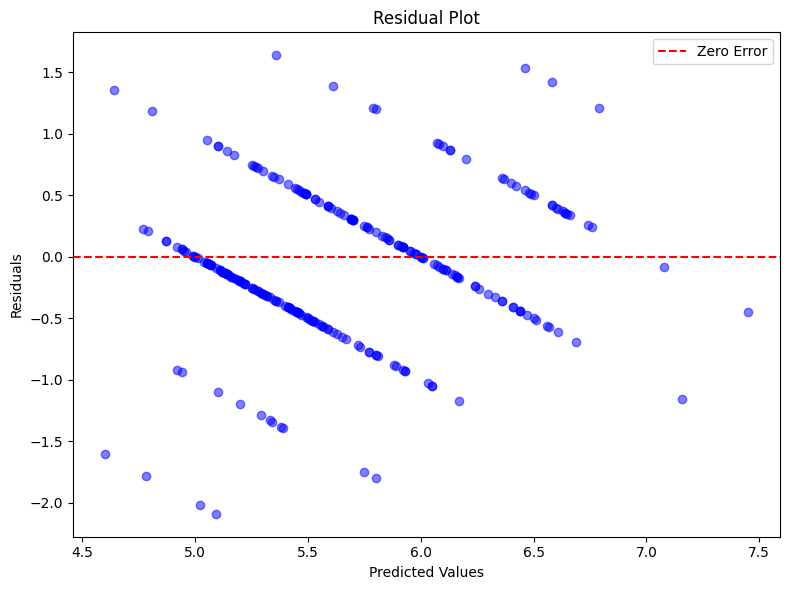

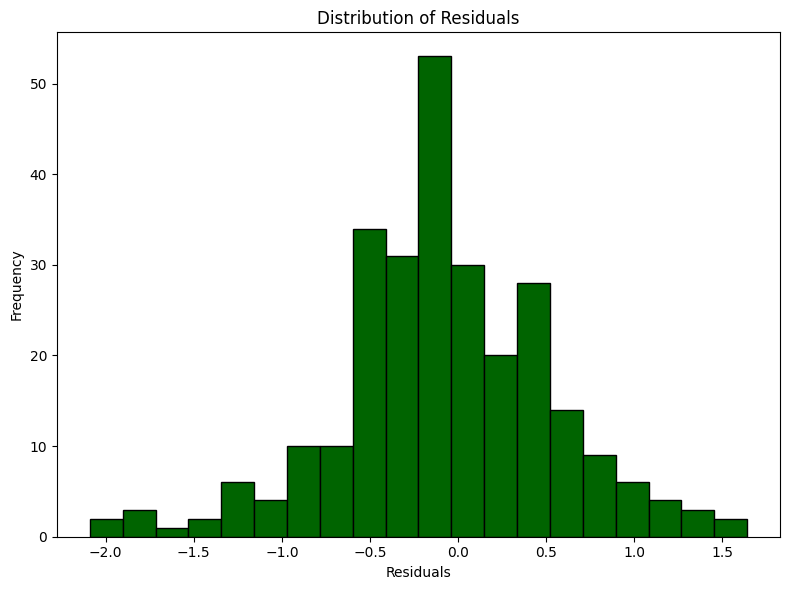

In [58]:
#Residual Analysis Plots

# Residual Plot

plt.figure(figsize=(8, 6))

# Scatter plot: Predicted values vs Residuals
plt.scatter(y_pred, residuals, alpha=0.5, color="blue")

# Reference line at zero
plt.axhline(y=0, color="red", linestyle="--", label="Zero Error")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.legend()
plt.tight_layout()
plt.show()

# Residual Distribution

plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=20,
    color="darkgreen",
    edgecolor="black"
)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.tight_layout()
plt.show()

Indices with the largest prediction errors:
[ 29 182 224]

Detailed Results:
Actual Value   : 4
Predicted Value: 5.80
Absolute Error : 1.80
------------------------------
Actual Value   : 3
Predicted Value: 5.02
Absolute Error : 2.02
------------------------------
Actual Value   : 3
Predicted Value: 5.09
Absolute Error : 2.09
------------------------------


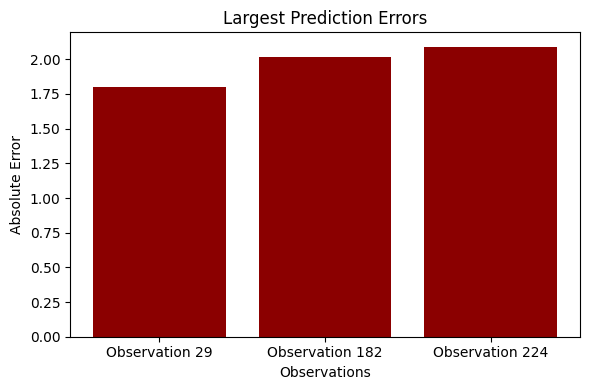

In [59]:
#  Analysis of the Largest Prediction Errors

# Calculate absolute prediction errors
errors = np.abs(y_test.values - y_pred)

# Identify the indices of the three largest errors
largest_errors_idx = np.argsort(errors)[-3:]

print("Indices with the largest prediction errors:")
print(largest_errors_idx)

print("\nDetailed Results:")
for i in largest_errors_idx:
    print(f"Actual Value   : {y_test.values[i]}")
    print(f"Predicted Value: {y_pred[i]:.2f}")
    print(f"Absolute Error : {errors[i]:.2f}")
    print("-" * 30)


# Visualize the largest prediction errors

labels = [f"Observation {i}" for i in largest_errors_idx]
values = errors[largest_errors_idx]

plt.figure(figsize=(6, 4))

plt.bar(
    labels,
    values,
    color="darkred"
)

plt.title("Largest Prediction Errors")
plt.xlabel("Observations")
plt.ylabel("Absolute Error")

plt.tight_layout()
plt.show()

In [60]:
# Linear Regression Coefficients

# Create a DataFrame containing the model coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

# Sort coefficients in descending order
coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

# Display the coefficients
coef_df



,Feature,Coefficient
10,alcohol,0.333970
9,sulphates,0.148499
5,free sulfur dioxide,0.048723
7,density,0.042064
3,residual sugar,-0.005231
2,citric acid,-0.019148
0,fixed acidity,-0.049675
4,chlorides,-0.115971
8,pH,-0.121548
6,total sulfur dioxide,-0.123600


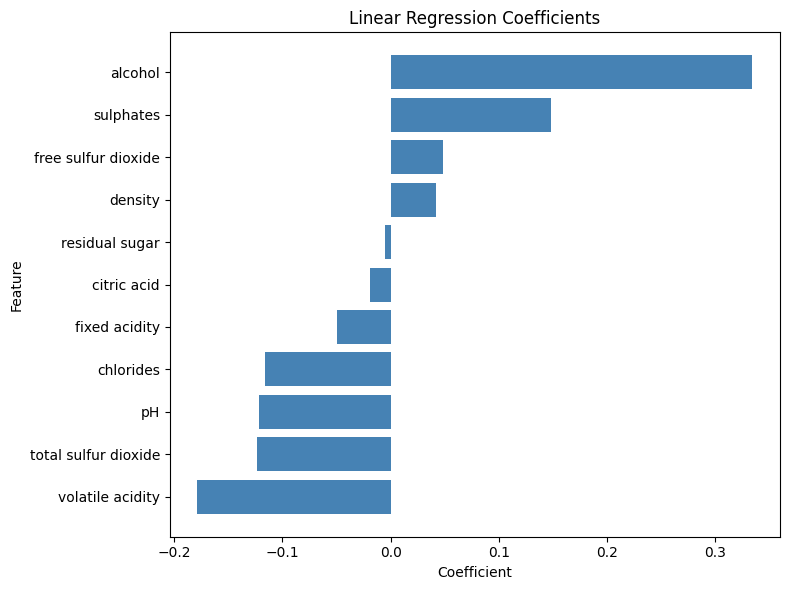

In [61]:
# Visualize Linear Regression Coefficients

plt.figure(figsize=(8, 6))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color="steelblue"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")

# Display the most influential features at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [62]:
# 8.2 Random Forest Feature Importance

# Create a DataFrame containing feature importance scores
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

# Sort features by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
importance_df

,Feature,Importance
10,alcohol,0.277586
9,sulphates,0.130236
1,volatile acidity,0.119547
6,total sulfur dioxide,0.081308
4,chlorides,0.064515
8,pH,0.062608
3,residual sugar,0.061190
7,density,0.055567
5,free sulfur dioxide,0.051433
0,fixed acidity,0.050361


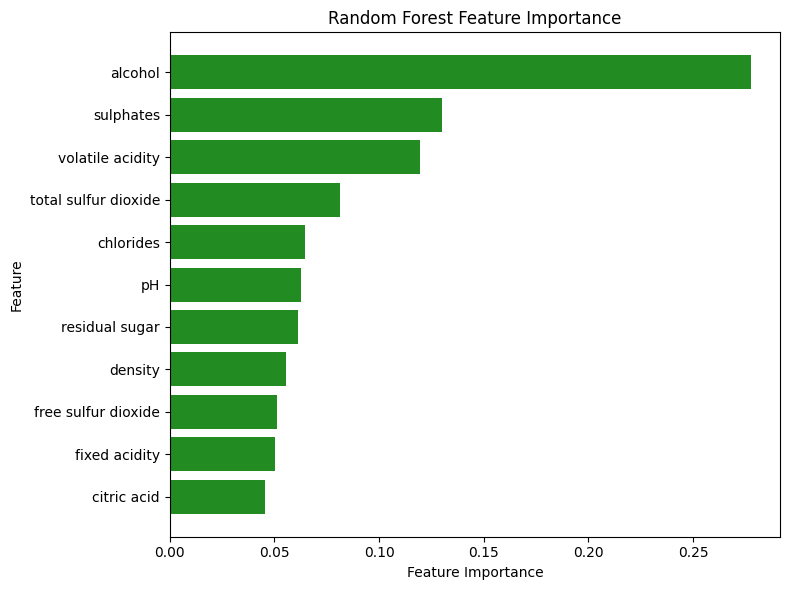

In [63]:
# Visualize Random Forest Feature Importance

plt.figure(figsize=(8, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color="forestgreen"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

# Display the most important features at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [64]:
#  SHAP Analysis

import shap

# Create a SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(forest_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

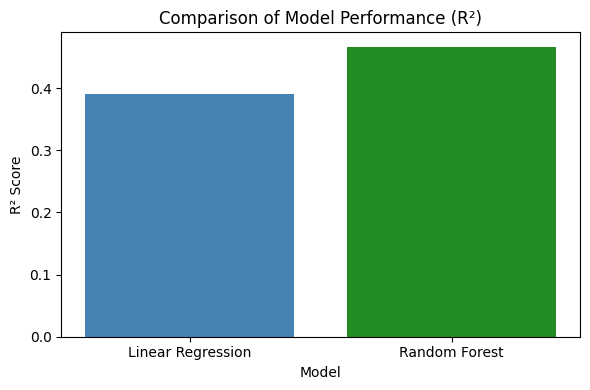

In [65]:
# Comparison of Model Performance

# Select the models to compare
models = ["Linear Regression", "Random Forest"]
r2_scores = results_df.loc[models, "R²"]

# Create the comparison chart
plt.figure(figsize=(6, 4))

plt.bar(
    models,
    r2_scores,
    color=["steelblue", "forestgreen"]
)

plt.title("Comparison of Model Performance (R²)")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()